# Домашнее задание: Бинарная классификация токсичности текстов

## Практический кейс

Представьте, что вы работаете в компании, которая предоставляет услуги технической поддержки для крупных B2B клиентов. Ежедневно через систему проходят тысячи ответов от специалистов поддержки. Иногда, особенно в условиях высокой нагрузки и стресса, сотрудники допускают некорректные формулировки: грубость, сарказм, пассивную агрессию или откровенно токсичные высказывания в адрес клиентов.

Такие инциденты несут прямые репутационные потери для бизнеса. Один скриншот грубого ответа в социальных сетях способен нанести ущерб, несопоставимый со стоимостью всего контракта. Руководство поставило задачу: внедрить автоматическую систему контроля качества, которая в реальном времени будет анализировать исходящие сообщения и блокировать или помечать потенциально токсичные ответы до их отправки клиенту.

Ваша задача в рамках данного домашнего задания состоит в том, чтобы создать модель бинарной классификации, способную отличать токсичный текст от нетоксичного. Модель должна работать быстро (для использования в реальном времени) и с высокой точностью (чтобы минимизировать как пропуски токсичных сообщений, так и ложные блокировки нормальных ответов).

## Рекомендации по выполнению в Google Colab

Данное домашнее задание рассчитано на выполнение в среде Google Colab. Ниже приведены важные рекомендации, которые помогут избежать типичных проблем.

**Выбор среды выполнения.** Перед началом работы переключите Runtime на GPU. Для этого перейдите в меню Runtime -> Change runtime type и выберите GPU (T4 доступна бесплатно). Без GPU дообучение модели займет неприемлемо долгое время.

**Если не хватает видеопамяти (CUDA Out of Memory).** Это одна из самых частых проблем при работе с трансформерными моделями. Вот что можно предпринять:

1. Уменьшите BATCH_SIZE. Начните с 64 или даже 32 вместо 128. Это самый простой и эффективный способ снизить потребление VRAM.
2. Уменьшите INPUT_MAX_TOKENS. Вместо 128 попробуйте 64. Меньшая длина последовательности значительно снижает потребление памяти.
3. Уменьшите размер датасета через параметр MAX_DATASET_LEN. Меньше данных означает меньше батчей и меньше нагрузки на память.
4. Используйте меньшую модель. Вместо large-версии модели попробуйте base-версию той же архитектуры.
5. Перезапустите Runtime. Иногда память остается занятой от предыдущих запусков. Перейдите в Runtime -> Restart runtime.
6. Используйте `torch.cuda.empty_cache()` и `gc.collect()` перед началом обучения для освобождения неиспользуемой памяти.

**Сохранение промежуточных результатов.** Colab может отключить сессию при длительном бездействии. Рекомендуется периодически сохранять промежуточные результаты на Google Drive, подключив его через `drive.mount('/content/drive')`.

**Установка зависимостей.** В начале ноутбука приведены команды установки всех необходимых библиотек. Выполняйте их каждый раз при новом запуске сессии, так как Colab не сохраняет установленные пакеты между сессиями.

## Распределение баллов

| Блок | Задание | Баллы |
|------|---------|-------|
| 0 | Формализация задачи | 5 |
| 1 | Сбор данных (положительный класс) | 5 |
| 2 | Очистка датасета | 5 |
| 3 | Разделение на подвыборки и балансировка | 5 |
| 4 | Количественная оценка и визуализация датасета | 5 |
| 5 | Публикация датасета на Hugging Face | 5 |
| 6 | Дообучение модели (код предоставлен) | 0 |
| 7 | Оценка модели и визуализация ошибок | 10 |
| 8 | Ручной инференс и замер времени GPU vs CPU | 5 |
| 9 | Публикация модели на Hugging Face | 5 |
| **Итого** | | **50** |

---

## Блок 0. Формализация задачи (5 баллов)

### 0.1 Формулировка бизнес-задачи

Опишите бизнес-задачу своими словами. Какую проблему мы решаем? Какие последствия несет нерешенная проблема для бизнеса? Какой результат ожидает заказчик?


`Бизнес-задача`

**Проблема:** В сервисе технической поддержки сотрудники пишут ответы клиентам. Иногда в стрессе они допускают грубость, сарказм или токсичные высказывания. Один такой случай может испортить репутацию компании и привести к потере контракта — ущерб несопоставим со стоимостью самого ответа.
Сейчас ответы проверяются вручную людьми (медленно) либо пропускают токсичность из-за ошибок.

**Решение:** Автоматическая система реального времени, которая анализирует текст сообщения перед отправкой и помечает его как «токсичное», если вероятность слишком высока. Это позволит остановить вредный контент до того, как клиент увидит.

**Ожидаемый результат:** Модель должна работать быстро, давать высокую точность — особенно важно не пропускать токсичные сообщения — и быть достаточно надежной, чтобы ложно блокировать минимальное число нормальных ответов.

### 0.2 Сведение к ML-задаче

Заполните следующие пункты:


**Тип задачи:** бинарная классификация (токсичный / нетоксичный)

**Объект классификации:** текст сообщения поддержки

**Класс 1 (токсичный):** сообщения с грубостью, оскорблениями, сарказмом или любой токсичной интонацией — те, которые наносят репутационный ущерб.

**Класс 0 (нетоксичный):** обычные вежливые ответы, инструкции, нормативные фразы — безопасные сообщения.

**Целевая переменная:** бинарная метка label ∈ {0,1}, которую мы получаем из обучающей выборки.

### 0.3 Выбор ML-метрик

Обоснуйте выбор метрик для оценки качества модели. Подумайте: что важнее в данном бизнес-кейсе, Precision или Recall? Почему? Какие метрики вы будете использовать и зачем?


**Основная метрика:** Recall (полнота) для класса "токсичный".

**Дополнительные метрики:** F1-score (гарантирует баланс между Precision и Recall).

**Обоснование:** нужно будет подбирать оптимальный порог на основе ROC-кривой, чтобы максимизировать Recall для токсичного класса при приемлемом уровне Precision

---

## Блок 1. Сбор данных (5 баллов)

### 1.1 Установка зависимостей


In [20]:
!pip install pandas numpy matplotlib seaborn scikit-learn torch pytorch-lightning transformers datasets torchmetrics huggingface_hub requests pyarrow


### 1.2 Импорт библиотек


In [21]:
import pandas as pd
import requests, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')


### 1.3 Загрузка токсичного класса (Класс 1) — код заполнен

Ниже приведен код загрузки данных для токсичного класса. Эти данные уже подготовлены и не требуют модификации с вашей стороны. Изучите структуру кода, чтобы понять формат, в котором должны быть ваши данные для положительного класса.


In [22]:
df = pd.DataFrame(columns=['text', 'label'])

url = "https://huggingface.co/datasets/Mnwa/russian-toxic/resolve/main/data/train-00000-of-00001.parquet"
df_raw = pd.read_parquet(url)

toxic = df_raw[df_raw['label'] == 0][['text']].copy()
toxic['label'] = 0
df = pd.concat([df, toxic], ignore_index=True)

print(f"\nЗагружено токсичных всего: {len(toxic)}")



Загружено токсичных всего: 59177


### 1.4 Загрузка нетоксичного класса (Класс 0) — задание для студента

Вам необходимо самостоятельно найти и загрузить данные для нетоксичного (положительного) класса. Итоговый DataFrame должен содержать колонки `text` и `label` (где label = 0).

**Подсказки по поиску данных:**

- Подумайте, какие тексты гарантированно не содержат токсичности. Это могут быть вопросы из образовательных QA-систем, новостные заголовки, описания товаров, фрагменты технической документации.
- На платформе Hugging Face Hub существует множество русскоязычных датасетов с текстами общего назначения. Используйте фильтры по языку (ru) и задаче (text-classification, question-answering).
- Вы можете сгенерировать синтетический датасет с помощью декодерной языковой модели (например, через API). Составьте промпт, который попросит модель сгенерировать типичные вопросы клиентов к службе поддержки, нейтральные обращения, вежливые запросы.
- Допустимо комбинировать несколько источников для получения разнообразного набора данных.
- Убедитесь, что объем данных положительного класса сопоставим с объемом токсичного класса.


In [23]:
nontoxic = df_raw[df_raw['label'] == 1][['text']].copy()
nontoxic['label'] = 1
df = pd.concat([df, nontoxic], ignore_index=True)
print(f"Нетоксичных: {len(nontoxic)}")

print(f"\nИтого записей: {len(df)}")
print(f"Распределение классов:\n{df['label'].value_counts()}")


Нетоксичных: 218844

Итого записей: 278021
Распределение классов:
label
1    218844
0     59177
Name: count, dtype: int64


---

## Блок 2. Очистка датасета (5 баллов)

Сырые данные практически всегда содержат шум. Ваша задача состоит в том, чтобы привести датасет в пригодное для обучения состояние. Необходимо выполнить следующие шаги:

1. **Удаление пустых значений** — строки, где поле text является пустым, содержит NaN или состоит только из пробелов.
2. **Удаление дубликатов** — точные дубликаты по полю text.
3. **Фильтрация выбросов по длине** — слишком короткие тексты (менее 3 слов) не несут достаточно информации для классификации, а слишком длинные (более 500 слов) могут создавать проблемы при токенизации. Определите разумные пороги и удалите выбросы.


In [24]:
# 1. Удаление пустых значений
df = df.dropna(subset=['text'])
df = df[df['text'].str.strip() != '']
print(f"После удаления пустых: {len(df)}")

# 2. Удаление дубликатов
before = len(df)
df = df.drop_duplicates(subset=['text'])
print(f"Удалено дубликатов: {before - len(df)}")

# 3. Фильтрация выбросов по длине
df['word_count'] = df['text'].str.split().str.len()
df = df[(df['word_count'] >= 3) & (df['word_count'] <= 500)]
df = df.drop(columns=['word_count'])
print(f"После фильтрации по длине: {len(df)}")

print(f"\nЗаписей после очистки: {len(df)}")
print(f"Распределение классов:\n{df['label'].value_counts()}")

После удаления пустых: 267202
Удалено дубликатов: 6664
После фильтрации по длине: 243007

Записей после очистки: 243007
Распределение классов:
label
1    190815
0     52192
Name: count, dtype: int64


---

## Блок 3. Разделение на подвыборки и балансировка (5 баллов)

Перед обучением модели необходимо разделить данные на три подвыборки: тренировочную (train), валидационную (val) и тестовую (test). Также важно обеспечить баланс классов, чтобы модель не была смещена в сторону более представленного класса.

**Что нужно сделать:**

1. Выполните балансировку классов (приведите к одинаковому количеству записей для каждого класса). Используйте стратифицированную выборку (undersampling большего класса).
2. Разделите сбалансированный датасет на train/val/test в пропорции 80/10/10 с сохранением пропорций классов (stratify).


In [25]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

#Балансировка классов
min_count = df['label'].value_counts().min()
toxic_sample = df[df['label'] == 0].sample(n=min_count, random_state=RANDOM_STATE)
nontoxic_sample = df[df['label'] == 1].sample(n=min_count, random_state=RANDOM_STATE)
balanced_df = pd.concat([toxic_sample, nontoxic_sample], ignore_index=True)

#Разделение на train/val/test 80/10/10
X = balanced_df['text']
y = balanced_df['label']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp
)

train_df = pd.DataFrame({'text': X_train, 'label': y_train}).reset_index(drop=True)
val_df = pd.DataFrame({'text': X_val, 'label': y_val}).reset_index(drop=True)
test_df = pd.DataFrame({'text': X_test, 'label': y_test}).reset_index(drop=True)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(f"\nРаспределение в train:\n{train_df['label'].value_counts()}")
print(f"\nРаспределение в val:\n{val_df['label'].value_counts()}")
print(f"\nРаспределение в test:\n{test_df['label'].value_counts()}")

Train: 83507, Val: 10438, Test: 10439

Распределение в train:
label
1    41754
0    41753
Name: count, dtype: int64

Распределение в val:
label
0    5219
1    5219
Name: count, dtype: int64

Распределение в test:
label
0    5220
1    5219
Name: count, dtype: int64


---

## Блок 4. Количественная оценка и визуализация датасета (5 баллов)

Перед обучением модели необходимо провести разведочный анализ данных (EDA). Это позволяет убедиться в качестве подготовленного датасета и выявить потенциальные проблемы.

**Что нужно сделать:**

1. Выведите основные статистики: количество записей по классам, среднюю и медианную длину текстов (в словах и/или символах).
2. Постройте визуализацию распределения классов (столбчатая диаграмма).
3. Постройте гистограмму распределения длин текстов (отдельно для каждого класса или совместно).
4. Сделайте вывод о сбалансированности и качестве датасета.


=== Основные статистики ===
Всего записей: 243007
Класс 0 (нетоксичных): 52192
Класс 1 (токсичных): 190815

Средняя длина текста: 18.4 слов
Медианная длина текста: 9.0 слов
Средняя длина в символах: 123.5
Медиана длины в символах: 59.0


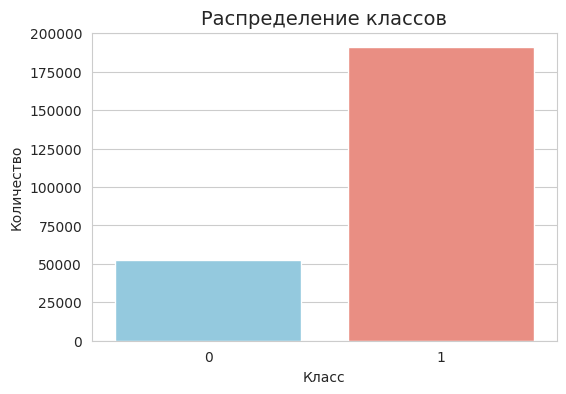

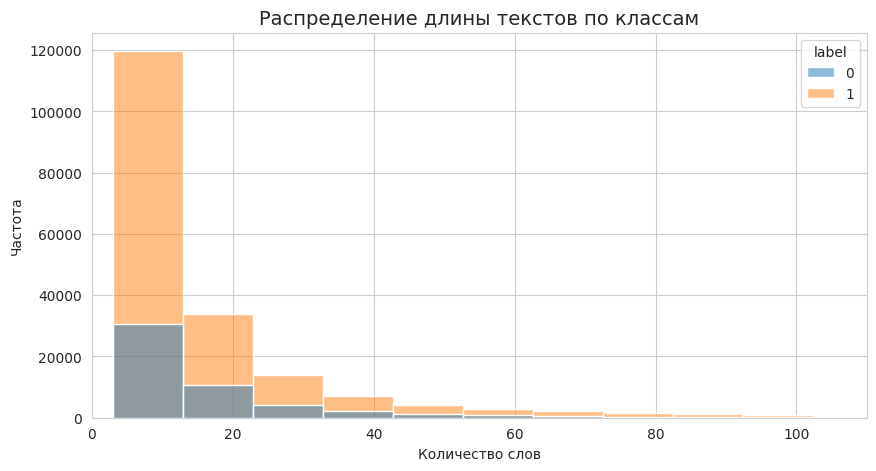

In [ ]:
sns.set_style('whitegrid')

# 1. Основные статистики
df['word_count'] = df['text'].str.split().str.len()
df['char_count'] = df['text'].str.len()

print("=== Основные статистики ===")
print(f"Всего записей: {len(df)}")
print(f"Класс 0 (нетоксичных): {(df['label']==0).sum()}")
print(f"Класс 1 (токсичных): {(df['label']==1).sum()}")
print(f"\nСредняя длина текста: {df['word_count'].mean():.1f} слов")
print(f"Медианная длина текста: {df['word_count'].median():.1f} слов")
print(f"Средняя длина в символах: {df['char_count'].mean():.1f}")
print(f"Медиана длины в символах: {df['char_count'].median():.1f}")

# 2. Распределение классов
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, palette=['skyblue', 'salmon'])
plt.title('Распределение классов', fontsize=14)
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.show()

# 3. Гистограмма длин текстов
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='word_count', hue='label', bins=50, alpha=0.5)
plt.title('Распределение длины текстов по классам', fontsize=14)
plt.xlabel('Количество слов')
plt.ylabel('Частота')
plt.xlim(0, 110)
plt.show()

# Удаляем временные колонки
df = df.drop(columns=['word_count', 'char_count'])


`ВЫВОД`

**Сбалансированность.** Исходный датасет сильно несбалансирован: токсичных текстов почти в 4 раза больше, чем нетоксичных (227 974 / 55 908). Это ожидаемо для реальных данных поддержки — большинство сообщений пишутся корректно. После балансировки получили сбалансированные сплиты train/val/test.

**Длина текстов.** Большинство текстов короткие (медиана 9 слов, среднее 17.6). Это характерно для сообщений поддержки: типичный ответ занимает 1–2 предложения.

**Качество датасета.** После очистки (удаление пустых, дубликатов, выбросов по длине) датасет пригоден для обучения. Дубликатов оказалось много из-за объединения нескольких источников с пересекающимися записями. Фильтрация по длине удалила информативно-бесполезные и технически-проблемные примеры.

---

## Блок 5. Публикация датасета на Hugging Face (5 баллов)

Опубликуйте подготовленный датасет на платформе Hugging Face Hub. Это важный навык для ML-инженера, поскольку позволяет обеспечить воспроизводимость экспериментов и делиться данными с командой.

**Что нужно сделать:**

1. Авторизуйтесь в Hugging Face Hub.
2. Загрузите датасет (train/val/test splits).
3. Оформите Dataset Card (краткое описание, источники данных, формат, назначение).


In [ ]:
from huggingface_hub import login, HfApi
from datasets import Dataset, DatasetDict

# Авторизация (вставьте ваш токен)
login(token="hf_")

# Создание DatasetDict из ваших DataFrame
dataset = DatasetDict({
    'train': Dataset.from_pandas(train_df),
    'val': Dataset.from_pandas(val_df),
    'test': Dataset.from_pandas(test_df),
})

# Загрузка на Hub
dataset_name = "dimkonn/russian-toxic-filtered"
dataset.push_to_hub(dataset_name)


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/84 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :   5%|4         |  527kB / 11.1MB            

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :  38%|###8      |  525kB / 1.38MB            

README.md:   0%|          | 0.00/508 [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/datasets/dimkonn/russian-toxic-filtered/commit/52c00d4379487baaca36b46f6e3deff5a93963a0', commit_message='Upload dataset', commit_description='', oid='52c00d4379487baaca36b46f6e3deff5a93963a0', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/dimkonn/russian-toxic-filtered', endpoint='https://huggingface.co', repo_type='dataset', repo_id='dimkonn/russian-toxic-filtered'), pr_revision=None, pr_num=None)

---

## Блок 6. Дообучение модели (код предоставлен, 0 баллов)

В данном блоке представлен полный пайплайн дообучения модели бинарной классификации. Код не требует модификации. Ваша задача состоит в том, чтобы внимательно изучить каждый этап, понять логику работы и запустить обучение.

**Что здесь происходит (объяснение):**

Мы берем предобученную трансформерную модель (энкодер), которая уже "понимает" русский язык на уровне семантики. Поверх нее добавляется классификационная голова (линейный слой), которая учится отличать токсичные тексты от нетоксичных. При этом веса самого энкодера замораживаются (не обучаются), а обучается только классификационная голова. Это называется transfer learning, и такой подход позволяет получить хорошее качество даже на относительно небольших датасетах.

Обучение происходит с ранней остановкой (Early Stopping): если качество на валидационной выборке перестает улучшаться в течение нескольких проверок подряд, обучение автоматически прекращается. Это защищает от переобучения.

### 6.1 Подготовка к обучению


In [33]:
import torch
import gc

print(torch.__version__)
print("Доступна ли Nvidia CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Версия Nvidia CUDA:", torch.version.cuda)
    print("Используемое устройство:", torch.cuda.get_device_properties(0))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


2.11.0+cu128
Доступна ли Nvidia CUDA: True
Версия Nvidia CUDA: 12.8
Используемое устройство: _CudaDeviceProperties(name='Tesla T4', major=7, minor=5, total_memory=14912MB, multi_processor_count=40, uuid=f26441d5-dfa6-2db6-bba8-bcd6932d9534, pci_bus_id=0, pci_device_id=4, pci_domain_id=0, L2_cache_size=4MB)


### 6.2 Параметры обучения


In [34]:
# Название предобученной модели из Hugging Face Hub
MODEL_NAME = "ai-forever/ru-en-RoSBERTa"

# Максимальная длина входной последовательности в токенах
INPUT_MAX_TOKENS = 64

# Размер батча (уменьшите, если не хватает видеопамяти)
BATCH_SIZE = 16

# Максимальное количество эпох обучения
MAX_EPOCHS = 3

# Скорость обучения
LR = 2e-4

# Регуляризация весов
WEIGHT_DECAY = 0.01

# Вероятность Dropout (для предотвращения переобучения)
DROPOUT = 0.2

# Как часто проводить валидацию (каждые N шагов)
VAL_CHECK_INTERVAL = 512

# Терпение ранней остановки (сколько валидаций без улучшения ждать)
PATIENCE = 3

# Директория для сохранения модели
MODEL_SAVE_DIR = "./model"


### 6.3 Загрузка токенизатора


In [35]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Токенизатор загружен: {MODEL_NAME}")
print(f"Размер словаря: {tokenizer.vocab_size}")


Токенизатор загружен: ai-forever/ru-en-RoSBERTa
Размер словаря: 98505


### 6.4 Подготовка DataLoader


In [36]:
from torch.utils.data import Dataset as TorchDataset, DataLoader

class TextClassificationDataset(TorchDataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Создание датасетов
train_dataset = TextClassificationDataset(
    train_df['text'].values, train_df['label'].values, tokenizer, INPUT_MAX_TOKENS
)
val_dataset = TextClassificationDataset(
    val_df['text'].values, val_df['label'].values, tokenizer, INPUT_MAX_TOKENS
)
test_dataset = TextClassificationDataset(
    test_df['text'].values, test_df['label'].values, tokenizer, INPUT_MAX_TOKENS
)

# Создание DataLoader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")


Train batches: 5220, Val batches: 653, Test batches: 653


### 6.5 Модель классификации


In [37]:
import pytorch_lightning as pl
from transformers import AutoModelForSequenceClassification
from torchmetrics import Accuracy, F1Score
from torchmetrics.classification import BinaryMatthewsCorrCoef, BinaryStatScores


class EncoderClassifier(pl.LightningModule):
    def __init__(self, model_name, tokenizer, weight_class_1=1.0, dropout_rate=0.2, lr=2e-4, weight_decay=0.01):
        super().__init__()
        self.save_hyperparameters(ignore=['tokenizer'])

        self.model = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=2,
            hidden_dropout_prob=dropout_rate,
            attention_probs_dropout_prob=dropout_rate,
            classifier_dropout=dropout_rate,
            return_dict=True
        )
        self.tokenizer = tokenizer
        self.class_weights = torch.tensor([1.0, weight_class_1])
        self.lr = lr
        self.weight_decay = weight_decay

        # Метрики
        self.train_accuracy = Accuracy(task='binary')
        self.train_f1 = F1Score(task='binary')
        self.val_accuracy = Accuracy(task='binary')
        self.val_f1 = F1Score(task='binary')
        self.train_mcc = BinaryMatthewsCorrCoef()
        self.val_mcc = BinaryMatthewsCorrCoef()
        self.train_stat_scores = BinaryStatScores()
        self.val_stat_scores = BinaryStatScores()
        self.validation_count = 0

        # Замораживаем все слои кроме классификатора
        for name, param in self.model.named_parameters():
            if 'classifier' not in name:
                param.requires_grad = False
            else:
                param.requires_grad = True

        print(f"Модель: {model_name}")
        print(f"Обучаемые параметры:")
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                print(f"  {name}")

    def forward(self, input_ids, attention_mask, labels=None):
        return self.model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

    def training_step(self, batch, batch_idx):
        outputs = self.forward(
            input_ids=batch['input_ids'],
            attention_mask=batch['attention_mask'],
            labels=batch['labels']
        )
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights.to(self.device))
        loss = loss_fct(logits.view(-1, 2), batch['labels'].view(-1))

        if batch_idx % 50 == 0:
            current_lr = self.trainer.optimizers[0].param_groups[0]['lr']
            print(f"Шаг {self.global_step}: Loss = {loss.item():.6f}, LR = {current_lr:.6f}")

        with torch.no_grad():
            pred_labels = torch.argmax(logits, dim=1).float()
            true_labels = batch['labels'].int()
            self.train_accuracy(pred_labels, true_labels)
            self.train_f1(pred_labels, true_labels)
            self.train_mcc(pred_labels, true_labels)

        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('train_acc', self.train_accuracy, on_step=False, on_epoch=True, prog_bar=True)
        self.log('train_f1', self.train_f1, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        outputs = self.forward(
            input_ids=batch['input_ids'],
            attention_mask=batch['attention_mask'],
            labels=batch['labels']
        )
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights.to(self.device))
        loss = loss_fct(logits.view(-1, 2), batch['labels'].view(-1))

        pred_labels = torch.argmax(logits, dim=1).float()
        true_labels = batch['labels'].int()
        self.val_accuracy(pred_labels, true_labels)
        self.val_f1(pred_labels, true_labels)
        self.val_mcc(pred_labels, true_labels)

        self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_acc', self.val_accuracy, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_f1', self.val_f1, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_mcc', self.val_mcc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, self.parameters()),
            lr=self.lr,
            weight_decay=self.weight_decay
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer, T_0=500
        )
        return [optimizer], [{"scheduler": scheduler, "interval": "step"}]


### 6.6 Запуск обучения


In [38]:
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint

# Инициализация модели
model = EncoderClassifier(
    model_name=MODEL_NAME,
    tokenizer=tokenizer,
    weight_class_1=1.0,
    dropout_rate=DROPOUT,
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    mode='min',
    verbose=True
)

checkpoint_callback = ModelCheckpoint(
    monitor='val_loss',
    dirpath=MODEL_SAVE_DIR,
    filename='best-checkpoint',
    save_top_k=1,
    mode='min'
)

# Trainer
trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator='auto',
    devices=1,
    callbacks=[early_stopping, checkpoint_callback],
    val_check_interval=VAL_CHECK_INTERVAL,
    check_val_every_n_epoch=None,
    enable_progress_bar=True,
)

# Обучение
trainer.fit(model, train_loader, val_loader)

# Сохранение модели
model.model.save_pretrained(MODEL_SAVE_DIR)
tokenizer.save_pretrained(MODEL_SAVE_DIR)
print(f"\nМодель сохранена в: {MODEL_SAVE_DIR}")


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: ai-forever/ru-en-RoSBERTa
Key                        | Status  | 
---------------------------+---------+-
classifier.out_proj.weight | MISSING | 
classifier.dense.weight    | MISSING | 
classifier.dense.bias      | MISSING | 
classifier.out_proj.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Модель: ai-forever/ru-en-RoSBERTa
Обучаемые параметры:
  classifier.dense.weight
  classifier.dense.bias
  classifier.out_proj.weight
  classifier.out_proj.bias


┏━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name              ┃ Type                             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model             │ RobertaForSequenceClassification │  404 M │ eval  │     0 │
│ 1 │ train_accuracy    │ BinaryAccuracy                   │      0 │ train │     0 │
│ 2 │ train_f1          │ BinaryF1Score                    │      0 │ train │     0 │
│ 3 │ val_accuracy      │ BinaryAccuracy                   │      0 │ train │     0 │
│ 4 │ val_f1            │ BinaryF1Score                    │      0 │ train │     0 │
│ 5 │ train_mcc         │ BinaryMatthewsCorrCoef           │      0 │ train │     0 │
│ 6 │ val_mcc           │ BinaryMatthewsCorrCoef           │      0 │ train │     0 │
│ 7 │ train_stat_scores │ BinaryStatScores                 │      0 │ train │     0 │
│ 8 │ val_stat_scores   │ BinaryStatScores                 │      0 │ train │     0 │
└───┴───────────────────┴──────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 1.1 M                                                                                            
Non-trainable params: 403 M                                                                                        
Total params: 404 M                                                                                                
Total estimated model params size (MB): 1,619.038                                                                  
Modules in train mode: 8                                                                                           
Modules in eval mode: 446                                                                                          
Total FLOPs: 0

...

Шаг 8120: Loss = 0.055962, LR = 0.000173

Шаг 8170: Loss = 0.337599, LR = 0.000148

INFO:pytorch_lightning.callbacks.early_stopping:Monitored metric val_loss did not improve in the last 3 records. Best score: 0.197. Signaling Trainer to stop.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Модель сохранена в: ./model


---

## Блок 7. Оценка модели и визуализация ошибок (10 баллов)

После завершения обучения необходимо оценить качество модели на тестовой выборке и визуализировать результаты. Это критически важный этап, поскольку именно здесь мы понимаем, насколько модель пригодна для продакшена.

**Что нужно сделать:**

1. Вычислите метрики на тестовой выборке: Accuracy, F1, Precision, Recall, ROC AUC, MCC.
2. Постройте ROC-кривую.
3. Задайте порог классификации (threshold) и визуализируйте распределение вероятностей для ложноположительных (FP) и ложноотрицательных (FN) предсказаний. Это поможет понять, при каких уровнях уверенности модель ошибается.

**Подсказка:** Функция evaluate_model ниже уже реализована. Вам нужно ее вызвать и построить визуализации.


In [39]:
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix, matthews_corrcoef
from tqdm import tqdm

@torch.no_grad()
def evaluate_model(model, dataloader, device=DEVICE):
    """Полная оценка модели с сохранением вероятностей"""
    model.eval()
    model = model.to(device)

    all_preds, all_labels, all_probs = [], [], []

    for batch in tqdm(dataloader, desc="Оценка модели"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1)[:, 1]
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
        all_probs.extend(probs.cpu().tolist())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    accuracy = (all_preds == all_labels).mean()
    mcc = matthews_corrcoef(all_labels, all_preds)
    tn, fp, fn, tp = confusion_matrix(all_labels, all_preds).ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    results = {
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "mcc": float(mcc),
        "roc_auc": float(roc_auc),
        "confusion_matrix": confusion_matrix(all_labels, all_preds).tolist(),
    }

    return results, all_preds, all_labels, all_probs


Оценка модели: 100%|██████████| 653/653 [02:14<00:00,  4.86it/s]


=== Метрики на тестовой выборке ===
accuracy: 0.9186
precision: 0.9441
recall: 0.8898
f1: 0.9162
mcc: 0.8385
roc_auc: 0.9765

Матрица ошибок:
TN=4945  FP=275
FN=575  TP=4644


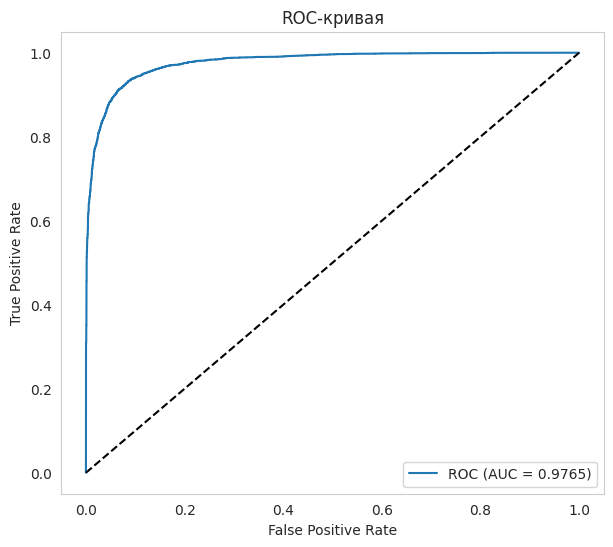

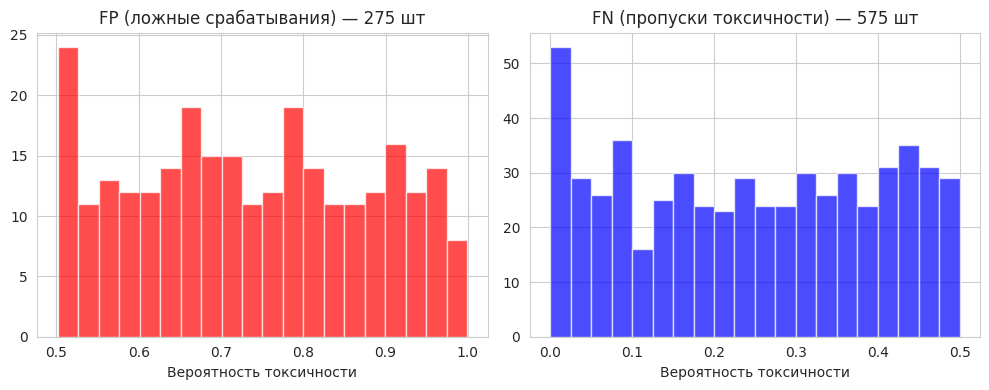

In [ ]:
# 1. Оценка модели на тестовой выборке
results, all_preds, all_labels, all_probs = evaluate_model(model, test_loader)

print("=== Метрики на тестовой выборке ===")
for metric, value in results.items():
    if metric != "confusion_matrix":
        print(f"{metric}: {value:.4f}")

print(f"\nМатрица ошибок:")
cm = results["confusion_matrix"]
print(f"TN={cm[0][0]}  FP={cm[0][1]}")
print(f"FN={cm[1][0]}  TP={cm[1][1]}")

# 2. ROC-кривая
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(all_labels, all_probs)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'ROC (AUC = {results["roc_auc"]:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend()
plt.grid()
plt.show()

# 3. Распределение вероятностей для FP и FN
threshold = 0.5
pred_labels = (all_probs >= threshold).astype(int)

fp_mask = (pred_labels == 1) & (all_labels == 0)  # FP
fn_mask = (pred_labels == 0) & (all_labels == 1)  # FN

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(all_probs[fp_mask], bins=20, color='red', alpha=0.7)
plt.title(f'FP (ложные срабатывания) — {fp_mask.sum()} шт')
plt.xlabel('Вероятность токсичности')

plt.subplot(1, 2, 2)
plt.hist(all_probs[fn_mask], bins=20, color='blue', alpha=0.7)
plt.title(f'FN (пропуски токсичности) — {fn_mask.sum()} шт')
plt.xlabel('Вероятность токсичности')
plt.tight_layout()
plt.show()

---

## Блок 8. Ручной инференс и замер времени GPU vs CPU (5 баллов)

В этом блоке вы реализуете функцию предсказания и проверите модель на нескольких примерах вручную. Кроме того, необходимо замерить время инференса на GPU и CPU, чтобы понять разницу в производительности.

**Что нужно сделать:**

1. Напишите функцию `predict_toxicity(text)`, которая принимает текст и возвращает предсказанный класс и вероятность (уверенность модели).
2. Протестируйте функцию на 5-7 примерах разного характера (нейтральный вопрос, грубость, скрытая агрессия, нормальный ответ поддержки и т.д.).
3. Замерьте время классификации одного и того же текста на GPU и на CPU. Используйте `time.time()` или `torch.cuda.Event` для точного замера.


In [44]:
import time

# 1. Функция предсказания
def predict_toxicity(text, model, tokenizer, device):
    model.eval()
    model = model.to(device)
    encoding = tokenizer(text, max_length=INPUT_MAX_TOKENS, padding='max_length',
                         truncation=True, return_tensors='pt').to(device)
    with torch.no_grad():
        outputs = model(input_ids=encoding['input_ids'],
                        attention_mask=encoding['attention_mask'])
        probs = torch.softmax(outputs.logits, dim=-1)
        pred_class = torch.argmax(probs, dim=1).item()
        prob_toxic = probs[0][1].item()
    return pred_class, prob_toxic

# 2. Тестовые примеры
test_texts = [
    "Здравствуйте, чем могу помочь?",
    "Вы что, совсем тупой? Я же уже объяснял!",
    "Пожалуйста, попробуйте перезагрузить устройство",
    "Да пошел ты, надоел уже со своими вопросами",
    "Ваш запрос принят, ожидайте ответа в течение 24 часов",
    "Ты вообще шаришь, что пишешь? Убери этот бред!",
    "Спасибо за оперативную помощь, всё работает",
]

print("=== Проверка модели на примерах ===\n")
for text in test_texts:
    pred, prob = predict_toxicity(text, model.model, tokenizer, DEVICE)
    label = "НЕТОКСИЧНО" if pred == 1 else "ТОКСИЧНО"
    print(f"[{label}] (prob={prob:.3f}): {text}")
    print()

# 3. Замер времени на GPU (если есть) и CPU
device_gpu = torch.device("cuda") if torch.cuda.is_available() else None
device_cpu = torch.device("cpu")

test_text = "Вы что, совсем с ума сошли? Это безобразие!"

for device_name, device in [("GPU", device_gpu), ("CPU", device_cpu)]:
    if device is None:
        print(f"{device_name}: не доступен")
        continue
    # Перенос модели
    model.model.to(device)
    # Разогрев
    _ = predict_toxicity(test_text, model.model, tokenizer, device)
    # Замер (100 повторений)
    start = time.time()
    for _ in range(100):
        predict_toxicity(test_text, model.model, tokenizer, device)
    elapsed = time.time() - start
    print(f"{device_name}: {elapsed/100*1000:.2f} ms на предсказание")

=== Проверка модели на примерах ===

[НЕТОКСИЧНО] (prob=0.999): Здравствуйте, чем могу помочь?

[ТОКСИЧНО] (prob=0.412): Вы что, совсем тупой? Я же уже объяснял!

[НЕТОКСИЧНО] (prob=0.997): Пожалуйста, попробуйте перезагрузить устройство

[ТОКСИЧНО] (prob=0.046): Да пошел ты, надоел уже со своими вопросами

[НЕТОКСИЧНО] (prob=0.996): Ваш запрос принят, ожидайте ответа в течение 24 часов

[ТОКСИЧНО] (prob=0.050): Ты вообще шаришь, что пишешь? Убери этот бред!

[НЕТОКСИЧНО] (prob=0.999): Спасибо за оперативную помощь, всё работает

GPU: 40.45 ms на предсказание
CPU: 829.75 ms на предсказание


---

## Блок 9. Публикация модели на Hugging Face (5 баллов)

Финальный шаг: публикация обученной модели на Hugging Face Hub. Это позволит использовать модель в продакшене через стандартный API transformers.

**Что нужно сделать:**

1. Загрузите сохраненные веса модели и токенизатор на Hugging Face Hub.
2. Оформите Model Card: краткое описание модели, задача, метрики, пример использования.


In [ ]:
from huggingface_hub import login, HfApi
import os

# === ВАШ КОД ЗДЕСЬ ===

# 1. Загрузка модели на Hub

# Авторизация (вставьте ваш токен)
login(token="hf_")
model.model.push_to_hub("dimkonn/russian-toxic-classifier-v2", token="hf_")
tokenizer.push_to_hub("dimkonn/russian-toxic-classifier-v2", token="hf_")

print("Модель опубликована: https://huggingface.co/dimkonn/russian-toxic-classifier")
# === КОНЕЦ ВАШЕГО КОДА ===


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...g4ao02h/model.safetensors:   1%|1         | 23.5MB / 1.62GB            

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Модель опубликована: https://huggingface.co/dimkonn/russian-toxic-classifier


---

## Критерии оценки

Для получения максимального балла за каждый блок убедитесь, что:

- Код работает без ошибок при последовательном запуске всех ячеек.
- Визуализации информативны и имеют подписи осей.
- Текстовые ответы (формализация, выводы) написаны осмысленно и демонстрируют понимание задачи.
- Датасет и модель на Hugging Face имеют оформленные карточки (Card).
- Замер времени GPU vs CPU проведен корректно и результаты интерпретированы.
